In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv"); df["match_date"]=pd.to_datetime(df["match_date"],errors="coerce"); print("Dataset loaded successfully"); print("Rows:",len(df)); print("Columns:",len(df.columns))

Dataset loaded successfully
Rows: 54600
Columns: 75


In [2]:
monthly=df.assign(month=df["match_date"].dt.to_period("M")).groupby("month")["goals"].sum().tail(24); monthly.index=monthly.index.astype(str); display(monthly)

month
2026-06    1101
2026-07    1923
Name: goals, dtype: int64

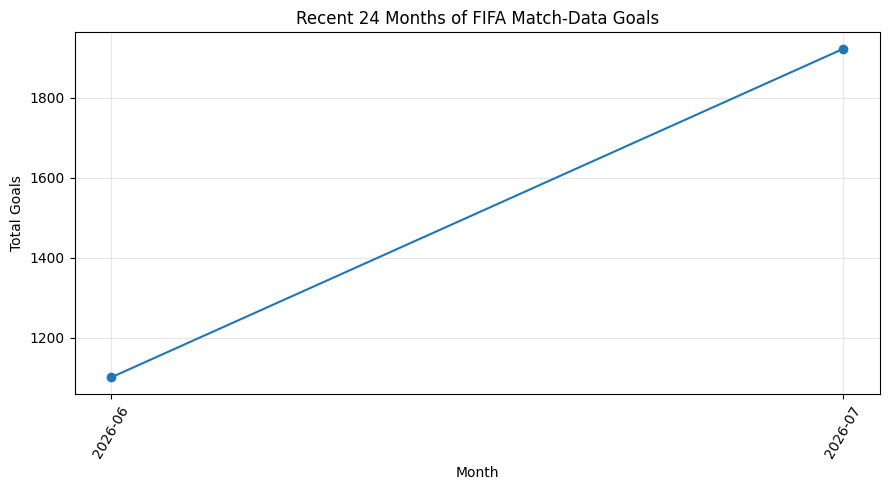

In [3]:
plt.figure(figsize=(9,5)); plt.plot(monthly.index,monthly.values,marker="o"); plt.title("Recent 24 Months of FIFA Match-Data Goals"); plt.xlabel("Month"); plt.ylabel("Total Goals"); plt.xticks(rotation=60); plt.grid(True,alpha=.3); plt.tight_layout(); plt.show()

In [4]:
stage_goals=df.groupby("tournament_stage")["goals"].sum(); display(stage_goals)

tournament_stage
Final                  62
Group Stage          1630
Quarter Finals        245
Round of 16           364
Round of 32           532
Semi Finals           134
Third Place Match      57
Name: goals, dtype: int64

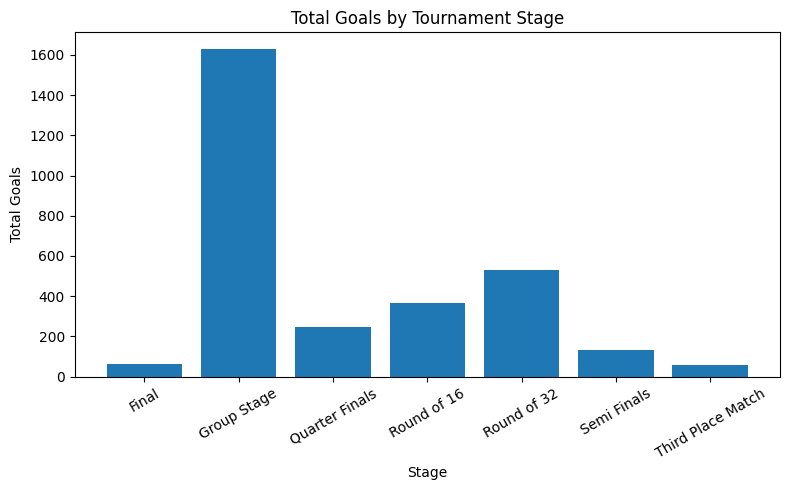

In [5]:
plt.figure(figsize=(8,5)); plt.bar(stage_goals.index.astype(str),stage_goals.values); plt.title("Total Goals by Tournament Stage"); plt.xlabel("Stage"); plt.ylabel("Total Goals"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

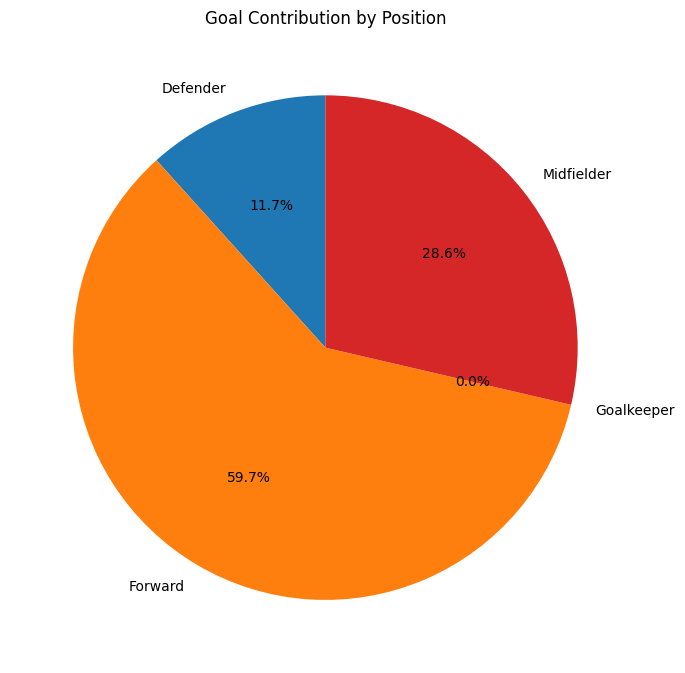

In [6]:
w=df.groupby("position")["goals"].sum(); plt.figure(figsize=(7,7)); plt.pie(w.values,labels=w.index,autopct="%1.1f%%",startangle=90); plt.title("Goal Contribution by Position"); plt.tight_layout(); plt.show()

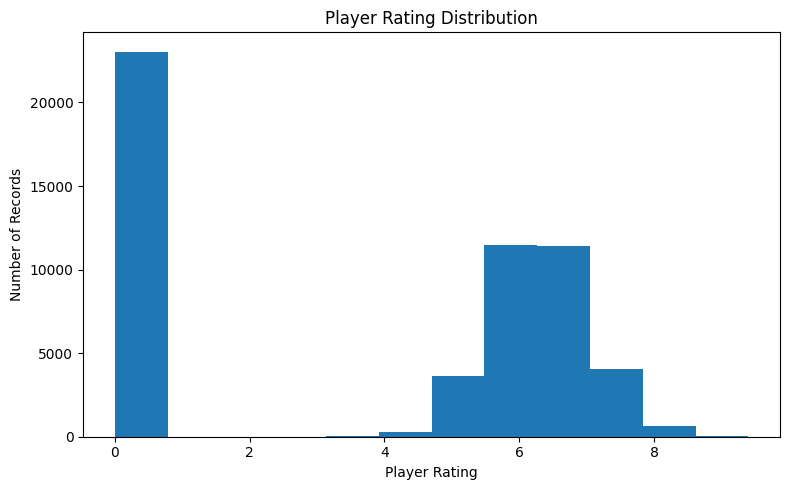

In [7]:
plt.figure(figsize=(8,5)); plt.hist(df["player_rating"],bins=12); plt.title("Player Rating Distribution"); plt.xlabel("Player Rating"); plt.ylabel("Number of Records"); plt.tight_layout(); plt.show()

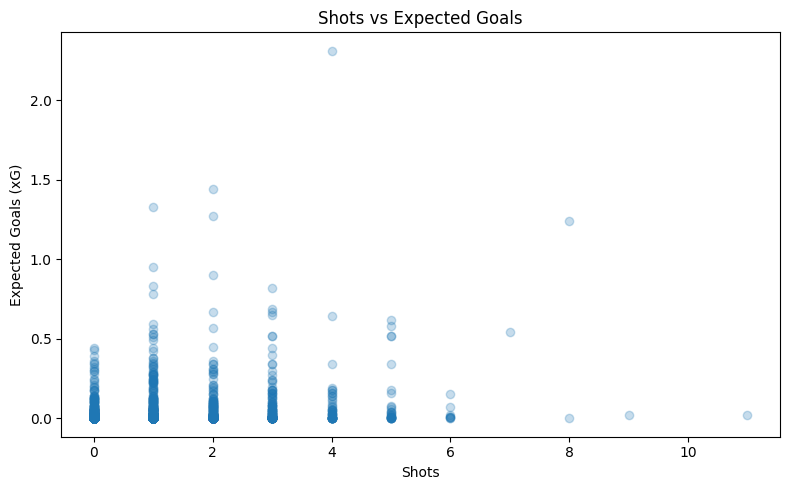

In [8]:
sample=df.sample(5000,random_state=42); plt.figure(figsize=(8,5)); plt.scatter(sample["shots"],sample["expected_goals_xg"],alpha=.25); plt.title("Shots vs Expected Goals"); plt.xlabel("Shots"); plt.ylabel("Expected Goals (xG)"); plt.tight_layout(); plt.show()